# Exercise 06 — Pretraining a Mini GPT

Last week you trained an encoder–decoder Transformer on **pairs**: a date as the source, its ISO form as the target. This week you drop the encoder, keep the decoder, and train it on **raw text** with a single objective: *predict the next character*. No labels, no pairs — the text is its own supervision. This is **pretraining**, and it is how GPT was made.

You build the model from scratch and pretrain it on **Tiny Shakespeare** (about 1 MB of Shakespeare's plays), following Andrej Karpathy's [`nanoGPT`](https://github.com/karpathy/nanoGPT). Karpathy's [YouTube lecture *Let's build GPT*](https://www.youtube.com/watch?v=kCc8FmEb1nY) builds the same model step by step; it is a great companion to this notebook.

The model is configured so that **pretraining takes a few minutes on a laptop CPU**. If you have a GPU, you can switch to a ten times larger configuration (see the setup cell). In notebook 1 you work with real pre-trained models: BERT, GPT-2 and T5.

## What you will do
1. **The data** — Shakespeare, a character vocabulary, and batches for next-character prediction.
2. **What loss should we expect?** — the loss of models that know (almost) nothing, to compare against.
3. **Causal self-attention** — all heads at once, checked against PyTorch's own implementation.
4. **The GPT model** — pre-norm blocks, embeddings, weight tying, and tests for causality.
5. **Pretraining** — overfit a few sequences, then train on Shakespeare.
6. **Generating text** — sampling, temperature and top-k.
7. **From mini GPT to GPT-3** — what changes with scale, and how much compute it takes.
8. **Multiple-choice questions** — to check your understanding.

## How to work through it
- Run the cells **in order** and fill in **every `# TODO`**.
- Tasks are numbered (**1.1**, **1.2**, …). Tasks that say *Your answer here* want a short written answer, not code.
- Most implementation tasks are followed by a **✅ Check** cell that verifies your work automatically. Run it and make sure it passes before you move on.

> **Tip — you have seen most of this before.** The attention, the causal mask, the position embeddings and teacher forcing are the ones from last week. What is new is *what* the model is trained on, a few changes to the block that GPT-2 introduced, and how you get text out of the model.

In [13]:
%matplotlib inline
import math
import os
import time
import urllib.request

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1337)

# Use the GPU if there is one; a CPU is enough for this notebook.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cpu device


### Hyperparameters

The values below define the size of the model and the training run. They are chosen so that pretraining (Part 5) takes a few minutes on a CPU. Leave them as they are for your first run.

In [14]:
# Model
block_size = 64   # context length: how many previous characters the model can see
n_embd = 128      # embedding dimension
n_head = 4        # attention heads per layer
n_layer = 4       # number of Transformer blocks
dropout = 0.0     # the small model hardly overfits in 2,000 steps

# Training
batch_size = 16      # sequences per batch
max_iters = 2000     # training steps
learning_rate = 1e-3
eval_interval = 250  # evaluate every ... steps
eval_iters = 50      # batches used to estimate the loss

# With a GPU you can afford Karpathy's original configuration (about 10 M parameters,
# ~15 minutes on a free T4 GPU on Colab or Kaggle). Uncomment the two lines below:
# block_size, n_embd, n_head, n_layer, dropout = 256, 384, 6, 6, 0.2
# batch_size, max_iters, learning_rate, eval_interval, eval_iters = 64, 5000, 3e-4, 500, 200

## 1. The data: Tiny Shakespeare

[Tiny Shakespeare](https://github.com/karpathy/char-rnn/tree/master/data/tinyshakespeare) is a single text file of about 1.1 million characters: 40,000 lines from Shakespeare's plays, concatenated. The cell below downloads it once and saves it as `input.txt` next to the notebook.

In [15]:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = "input.txt"

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

with open(DATA_PATH, encoding="utf-8") as f:
    text = f.read()

print(f"{len(text):,} characters\n")
print(text[:500])

1,115,394 characters

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


### A character vocabulary

As last week, the model works on **characters**. This time the vocabulary is simply every character that occurs in the text — letters, digits, punctuation, space and newline — and we need no special tokens.

**1.1 Complete the vocabulary, `encode` and `decode`.**

Hint: `set(text)` gives you the distinct characters. Sort them, so that the ids do not change between runs.

In [16]:
chars = sorted(set(text))  # TODO: sorted list of the distinct characters in text
vocab_size = len(chars)
stoi = dict((c, i) for i, c in enumerate(chars))   # TODO: dictionary character -> id
itos = dict(enumerate(chars))   # TODO: dictionary id -> character


def encode(s):
    # "hi" -> [id of "h", id of "i"]
    return [stoi[c] for c in s]  # TODO


def decode(ids):
    # The inverse of encode
    return "".join([itos[i] for i in ids])  # TODO


print(f"{vocab_size} characters:", repr("".join(chars)))
print(encode("Hello there!"))

65 characters: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
[20, 43, 50, 50, 53, 1, 58, 46, 43, 56, 43, 2]


In [17]:
# ✅ Check your vocabulary
assert vocab_size == 65, f"Tiny Shakespeare has 65 distinct characters, got {vocab_size}"
assert list(chars) == sorted(chars), "chars should be sorted"
assert encode("\n !") == [0, 1, 2], "with a sorted vocabulary, newline, space and '!' get the ids 0, 1 and 2"
assert decode(encode("To be, or not to be")) == "To be, or not to be", "decode(encode(s)) should give back s"
print("Looks good ✅")

Looks good ✅


We encode the whole text once, and keep the last 10% for validation:

In [18]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"{len(train_data):,} characters for training, {len(val_data):,} for validation")

1,003,854 characters for training, 111,540 for validation


### Batches for next-character prediction

A training example is a random chunk of the text. From a chunk of `block_size + 1` characters we get the input `x` (all but the last character) and the target `y` (all but the first):

```
chunk    F  i  r  s  t  ␣  C
x        F  i  r  s  t  ␣        positions 0 .. block_size - 1
y        i  r  s  t  ␣  C        the next character at every position
```

`y[t]` is the character the model has to predict after it has seen `x[0], ..., x[t]`. This is **teacher forcing** again, exactly as in last week's decoder — except that input and target now come from the *same* text. No one has to label anything, which is why this kind of training is called **self-supervised**.

**1.2 Complete `get_batch`.**

Hints:
- `torch.randint(high, (batch_size,))` draws `batch_size` random integers from `0, ..., high - 1`. Every chunk needs `block_size + 1` characters, so a chunk must not start too close to the end of the data.
- `torch.stack` turns a list of tensors of shape `(block_size,)` into one tensor of shape `(batch_size, block_size)`.

In [55]:
def get_batch(split):
    # A batch of random chunks: x and y of shape (batch_size, block_size), y shifted by one position.
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))  # TODO: batch_size random start positions
    # print(f"{split = }, {block_size = }, {batch_size = } {ix.shape = } {data.shape = }")
    x = torch.stack([data[i:i+block_size] for i in ix])   # TODO: stack data[i : i + block_size] for every i in ix
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])   # TODO: stack data[i + 1 : i + block_size + 1] for every i in ix
    return x.to(device), y.to(device)

In [56]:
# ✅ Check your batches
x, y = get_batch("train")
assert x.shape == (batch_size, block_size) and y.shape == (batch_size, block_size), "x and y should have shape (batch_size, block_size)"
assert torch.equal(x[:, 1:], y[:, :-1]), "y should be x shifted by one position"
for _ in range(200):  # chunks must never run past the end of the data
    xv, yv = get_batch("val")
    assert xv.shape == yv.shape == (batch_size, block_size), "a chunk ran past the end of the data"

print("x:", repr(decode(x[0].tolist())))
print("y:", repr(decode(y[0].tolist())))
print("Looks good ✅")

x: 'nd ours:\nTherefore, Lord Oxford, to prevent the worst,\nForthwith'
y: 'd ours:\nTherefore, Lord Oxford, to prevent the worst,\nForthwith '
Looks good ✅


**1.3 One chunk of `block_size + 1` characters gives `block_size` training examples at once.** What are they — what does the model see, and what does it have to predict, in each of them? Why is the job at position 0 harder than at position 63? And why do we not need the `<s>`, `</s>` and `<pad>` tokens of last week?

---

*Your answer here:*

---

## 2. What loss should we expect?

Before you build a model, it helps to know which numbers to expect. Two baselines:

- A model that knows **nothing** gives every character the same probability, $1/65$.
- A model that only knows **how often each character occurs** (a *unigram* model) gives every character its relative frequency in the training data, no matter what came before.

The loss we use is the cross-entropy: the average of $-\log p(\text{correct character})$.

**2.1 Compute the loss of both baselines** — for the unigram model, on the validation data.

Hint: `unigram_probs[val_data]` looks up the probability of every validation character at once.

In [72]:
uniform_loss = - math.log(1 / vocab_size)  # TODO: the cross-entropy of a uniform guess over the vocabulary (a Python float)

counts = torch.bincount(train_data, minlength=vocab_size).float()
unigram_probs = counts / len(train_data)  # TODO: relative frequency of every character in the training data, shape (vocab_size,)
unigram_loss = - unigram_probs[val_data].log().mean().item()   # TODO: average negative log-probability of the validation characters (a Python float)

print(f"uniform: loss {uniform_loss:.3f}")
print(f"unigram: loss {unigram_loss:.3f}")

uniform: loss 4.174
unigram: loss 3.347


In [73]:
# ✅ Check your baselines
assert abs(uniform_loss - 4.174) < 1e-3, "the uniform loss is -log(1/65)"
assert torch.isclose(unigram_probs.sum(), torch.tensor(1.0)), "the unigram probabilities should sum to 1"
assert 2.8 < unigram_loss < 3.6, f"the unigram loss should be a bit above 3, got {unigram_loss:.3f}"
print("Looks good ✅")

Looks good ✅


**2.2 Turn the losses into perplexities** (you met perplexity in week 3: $\text{PPL} = e^{\text{loss}}$). What does the perplexity of the uniform model tell you? Your model in Part 5 should reach a validation loss of about 2.0 or lower. What perplexity is that, and how would you explain it in words?

---

*Your answer here:*

We use $e^{-\frac 1 N \sum_{i=1}^N \ln(P(w_i))}$.

We then have
$$Perplexity_{uniform} = e^{-\frac 1 N \sum_{i=1}N 4.174} = e^{4.174} \approx 64.9748$$
along with
$$Perplexity_{unigram} = e^{-\frac 1 N \sum_{i=1}N 3.347} = e^{3.347} \approx 28.4174.$$

For the upcomming model, we achieve $Perplexity_{model} \approx e^2 \approx 7.3891$, which means that at each step, the model is
as certain as if it had to predict between 7-8 words.

---

## 3. Causal self-attention

Last week your `MultiHeadAttention` was general: queries, keys and values could come from different sequences (for cross-attention), and the mask was passed in from outside. A GPT only ever needs one kind of attention — **self-attention with a causal mask** — so we write a version specialised for that, the way GPT-2 does it:

- **One** linear layer computes queries, keys and values together (`n_embd -> 3 * n_embd`), and the result is split into three.
- The causal mask is stored inside the module, as a **buffer**: a tensor that moves to the GPU with `.to(device)` but is not a parameter and is not trained. It is built once for the full `block_size`, so for a shorter input of length `T` you have to use only its top-left `T × T` corner.

The splitting into heads, the scaling and the softmax are the same as last week.

**3.1 Complete the `forward` method of `CausalSelfAttention`.**

Hints:
- Split into heads as last week: `view(B, T, n_head, head_dim)`, then `transpose(1, 2)`.
- The mask is `True` where attention is **allowed**.
- Undo the split with `transpose(1, 2)` and `reshape(B, T, C)`.

In [86]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.0):
        super().__init__()
        assert n_embd % n_head == 0, "n_embd must be divisible by n_head"
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)  # queries, keys and values of all heads in one matrix multiplication
        self.proj = nn.Linear(n_embd, n_embd)     # output projection after the heads are concatenated
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        # The causal mask, True where attention is allowed
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size, dtype=torch.bool)))

    def forward(self, x):
        # x: (B, T, C) with T <= block_size -> (B, T, C)
        B, T, C = x.shape

        # 1) Queries, keys and values: one projection, split into three tensors of shape (B, T, C)
        q, k, v = self.qkv(x).split(C, dim=-1)

        # 2) Split into heads -> (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, -1).transpose(1, 2)  # TODO
        k = k.view(B, T, self.n_head, -1).transpose(1, 2)  # TODO
        v = v.view(B, T, self.n_head, -1).transpose(1, 2)  # TODO

        # 3) Causal scaled dot-product attention
        scores = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))   # TODO: (B, n_head, T, T), scaled by the square root of head_dim
        scores = scores.masked_fill(~self.get_buffer("mask")[:T, :T], -math.inf)   # TODO: -inf wherever the mask is False (use the T x T corner of self.mask)
        weights = torch.softmax(scores, dim=-1)  # TODO: softmax over the keys
        weights = self.attn_dropout(weights)
        out = weights @ v      # TODO: weighted sum of the values, (B, n_head, T, head_dim)

        # 4) Concatenate the heads -> (B, T, C), then the output projection
        out = out.transpose(1, 2).reshape(B, T, -1)      # TODO
        return self.resid_dropout(self.proj(out))

PyTorch has a fused implementation of exactly this computation, `F.scaled_dot_product_attention`, which real models use because it is much faster and needs less memory (it never stores the full `T × T` matrix). The check compares your module with it.

In [85]:
# ✅ Check your attention against F.scaled_dot_product_attention
torch.manual_seed(0)
attn = CausalSelfAttention(n_embd=32, n_head=4, block_size=16)
x = torch.randn(2, 10, 32)  # T = 10, shorter than block_size

with torch.no_grad():
    out = attn(x)
    assert out.shape == (2, 10, 32), f"the output should have shape (2, 10, 32), got {tuple(out.shape)}"

    q, k, v = attn.qkv(x).split(32, dim=-1)
    q, k, v = (t.view(2, 10, 4, 8).transpose(1, 2) for t in (q, k, v))
    reference = F.scaled_dot_product_attention(q, k, v, is_causal=True)
    reference = attn.proj(reference.transpose(1, 2).reshape(2, 10, 32))
    assert torch.allclose(out, reference, atol=1e-5), "your output differs from PyTorch's — check the split into heads, the scaling and the mask"

    x_changed = x.clone()
    x_changed[:, 6:] = torch.randn(2, 4, 32)  # change the future ...
    assert torch.allclose(attn(x_changed)[:, :6], out[:, :6], atol=1e-5), "position t can see positions after t — check the mask"
print("Looks good ✅")

Looks good ✅


**3.2 Two questions about the differences from last week.**
1. GPT-2 computes queries, keys and values with *one* `nn.Linear(n_embd, 3 * n_embd)` instead of three `nn.Linear(n_embd, n_embd)`. Does that change the number of parameters, or what the model can compute? Why do it?
2. Last week you needed a **padding mask** besides the causal mask. Why does this model not need one?

---

*Your answer here:*

---

## 4. The GPT model

### The block

Last week's layers used **post-norm**: the layer norm came *after* the residual connection, `x = LayerNorm(x + SubLayer(x))`. GPT-2 — and almost every large language model since — uses **pre-norm**:

```
x = x + SubLayer(LayerNorm(x))
```

The sub-layer gets a normalised input, but its result is added to an *un*normalised residual stream. That gives every layer an untouched "highway" from the input to the output, which makes deep stacks much easier to train.

A GPT block has two sub-layers: causal self-attention ("the positions talk to each other") and an MLP ("every position thinks on its own"). GPT uses the smooth **GELU** activation instead of the ReLU of last week.

**4.1 Complete the `forward` method of `Block`.**

In [88]:
class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: (B, T, C) -> (B, T, C)
        x = x + self.attn(self.ln1(x))  # TODO: pre-norm self-attention with a residual connection
        x = x + self.mlp(self.ln2(x))  # TODO: pre-norm MLP with a residual connection
        return x

### The model

The full model is last week's decoder without the cross-attention:

1. **Token embeddings** plus learned **position embeddings** (positions `0 .. T-1`).
2. The stack of blocks.
3. A **final layer norm**. With pre-norm, the output of the last block has never been normalised, so this one is needed.
4. The **language-modelling head**, a linear layer that turns every position's vector into logits over the vocabulary.

Two details from GPT-2 are already in the `__init__` below:
- **Weight tying:** the head uses *the same* weight matrix as the token embedding. The vector that represents a character at the input is also the one used to score it at the output.
- **Initialisation:** all weights are drawn from a normal distribution with a small standard deviation (0.02).

**4.2 Complete `GPT.forward`.**

Hints:
- `torch.arange(T, device=idx.device)` gives the position ids.
- `F.cross_entropy` expects logits of shape `(N, vocab_size)` and targets of shape `(N,)`: flatten batch and time with `.reshape(-1, ...)` — every position of every sequence is one prediction.

In [106]:
class GPT(nn.Module):
    def __init__(self, vocab_size, block_size, n_embd, n_head, n_layer, dropout=0.0):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight  # weight tying: one matrix for the input and the output
        self.apply(self._init_weights)

    def _init_weights(self, module):
        # Small random weights and zero biases, as in GPT-2
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def forward(self, idx, targets=None):
        # idx: (B, T) token ids with T <= block_size; targets: (B, T) token ids, or None
        # Returns the logits (B, T, vocab_size) and the loss (None if there are no targets).
        B, T = idx.shape

        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))       # TODO: token embeddings + position embeddings
        x = self.drop(x)
        x = self.ln_f(self.blocks(x))       # TODO: the blocks, then the final layer norm
        logits = self.lm_head(x)  # TODO: the language-modelling head

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1)
            )  # TODO: the cross-entropy over all B * T positions
        return logits, loss

The check tests the behaviour that matters, as last week: the shapes, the loss of an untrained model (compare it with Part 2!), that positions are used, and that no position can see the future.

In [107]:
# ✅ Check your model
torch.manual_seed(0)
model = GPT(vocab_size, block_size, n_embd, n_head, n_layer, dropout).to(device)
model.eval()
xb, yb = get_batch("train")

with torch.no_grad():
    logits, loss = model(xb, yb)
    assert logits.shape == (batch_size, block_size, vocab_size), f"the logits should have shape {(batch_size, block_size, vocab_size)}, got {tuple(logits.shape)}"
    assert model(xb)[1] is None, "without targets the loss should be None"
    assert abs(loss.item() - uniform_loss) < 0.1, f"an untrained model should have a loss close to the uniform baseline ({uniform_loss:.2f}), got {loss.item():.2f}"

    # Positions: the same character at two positions must not get the same output
    same = torch.full((1, 8), stoi["a"], device=device)
    same_logits, _ = model(same)
    assert not torch.allclose(same_logits[0, 0], same_logits[0, 1], atol=1e-5), "the model ignores positions — did you add the position embeddings?"

    # Causality: changing characters from position 40 onwards must not change the logits before it
    changed = xb.clone()
    changed[:, 40:] = stoi["z"]
    changed_logits, _ = model(changed)
    assert torch.allclose(logits[:, :40], changed_logits[:, :40], atol=1e-5), "the model can see the future"
    assert not torch.allclose(logits[:, 40:], changed_logits[:, 40:], atol=1e-5), "the model ignores its input"

n_params = sum(p.numel() for p in model.parameters())  # the tied matrix is counted once
expected = n_layer * (12 * n_embd**2 + 13 * n_embd) + (vocab_size + block_size) * n_embd + 2 * n_embd
print(f"The model has {n_params:,} parameters")
assert n_params == expected, f"expected {expected:,} parameters"
print("Looks good ✅")

print(f"Tying saves {model.tok_emb.weight.numel() = } parameters")

The model has 809,856 parameters
Looks good ✅
Tying saves model.tok_emb.weight.numel() = 8320 parameters


**4.3 How many parameters does weight tying save** in our model? GPT-2 small has a vocabulary of 50,257 tokens, an embedding dimension of 768 and 124 M parameters (with tying). How many parameters does tying save there, and what fraction of the model is that? Why is the difference so large?

---

*Your answer here:*
See print in cell above.

---

## 5. Pretraining

`estimate_loss` averages the loss over a number of random batches from each split. It switches the model to evaluation mode (no dropout) and back.

In [108]:
@torch.no_grad()
def estimate_loss(model):
    # The average loss over eval_iters random batches of the training and validation data
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            x, y = get_batch(split)
            _, loss = model(x, y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

**5.1 Complete `train_step`.** It is the same as last week's, only simpler: the model computes the loss itself.

In [112]:
def train_step(model, optimizer, xb, yb):
    # One optimisation step on a batch; returns the loss as a Python float.
    model.train()
    _, loss = model(xb, yb)  # TODO: forward pass with targets

    # TODO: zero the gradients, backpropagate and update the weights
    optimizer.zero_grad()
    loss.backward()
    # nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Provided solution does not clip.
    optimizer.step()

    return loss.item()

### Overfit a few sequences first

As last week: before the long run, check that the model can **memorise** a handful of sequences. If it cannot, something is broken, and training longer will not fix it.

In [113]:
# ✅ Check your training step: memorise 4 sequences
torch.manual_seed(0)
tiny_model = GPT(vocab_size, block_size, n_embd, n_head, n_layer).to(device)
tiny_optimizer = torch.optim.AdamW(tiny_model.parameters(), lr=1e-3)
xb, yb = get_batch("train")
xb, yb = xb[:4], yb[:4]

for step in range(1, 301):
    loss = train_step(tiny_model, tiny_optimizer, xb, yb)
    if step % 100 == 0:
        print(f"step {step}: loss {loss:.4f}")

assert loss < 0.5, "the model cannot memorise 4 sequences — check train_step and the model"
print("Looks good ✅")

step 100: loss 0.0534
step 200: loss 0.0195
step 300: loss 0.0127
Looks good ✅


### The training run

**5.2 Run the cell below** to pretrain the model on Shakespeare. It prints the training and validation loss every `eval_interval` steps. With the default configuration this takes a few minutes on a CPU (about 3–6 minutes on a laptop); with the GPU configuration about 15 minutes on a T4.

We use **AdamW**, the variant of Adam that almost every Transformer is trained with.

0.81 M parameters
step     0: train loss 4.2082, val loss 4.2055   (2 s)
step   250: train loss 2.4372, val loss 2.4341   (17 s)
step   500: train loss 2.2243, val loss 2.2541   (32 s)
step   750: train loss 2.0521, val loss 2.1021   (44 s)
step  1000: train loss 1.9377, val loss 2.0398   (56 s)
step  1250: train loss 1.8403, val loss 1.9481   (67 s)
step  1500: train loss 1.7811, val loss 1.8916   (81 s)
step  1750: train loss 1.7188, val loss 1.8650   (94 s)
step  2000: train loss 1.6656, val loss 1.8236   (110 s)


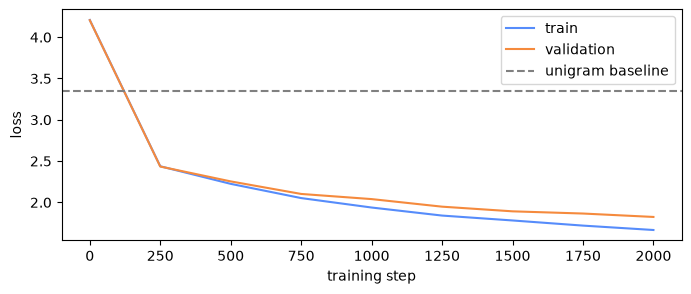

In [114]:
torch.manual_seed(1337)
model = GPT(vocab_size, block_size, n_embd, n_head, n_layer, dropout).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f} M parameters")

history = []
start = time.time()
for step in range(max_iters + 1):
    if step % eval_interval == 0 or step == max_iters:
        losses = estimate_loss(model)
        history.append((step, losses["train"], losses["val"]))
        print(f"step {step:>5}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}   ({time.time() - start:.0f} s)")
    if step < max_iters:
        xb, yb = get_batch("train")
        train_step(model, optimizer, xb, yb)

steps, train_losses, val_losses = zip(*history)
plt.figure(figsize=(8, 3))
plt.plot(steps, train_losses, label="train")
plt.plot(steps, val_losses, label="validation")
plt.axhline(unigram_loss, color="gray", linestyle="--", label="unigram baseline")
plt.xlabel("training step")
plt.ylabel("loss")
plt.legend()
plt.show()

In [ ]:
# ✅ Check the result
final_val_loss = history[-1][2]
assert final_val_loss < 2.3, f"the validation loss should be clearly below 2.3, got {final_val_loss:.3f}"
print("Looks good ✅")

**5.3 Look at the curves.** Do you see overfitting? What does that tell you about where the model's limits are — model size, data, or training time? Karpathy's larger configuration uses `dropout = 0.2`; why does the larger model need it, when ours does not?

---

*Your answer here:*

Very limited. val loss is only slightly higher than train loss.
A larger model with more parameters starts overfitting much easier.

---

## 6. Generating text

The model gives a probability distribution over the next character. To generate text we start with a **prompt**, repeatedly pick a next character from that distribution, and append it — as in last week's greedy decoding. But instead of always taking the most likely character, we **sample**, and we can shape the distribution first:

- **Temperature** $\tau$: divide the logits by $\tau$ before the softmax. $\tau < 1$ makes the distribution sharper (safer, more repetitive), $\tau > 1$ flatter (more surprising, more mistakes). $\tau \to 0$ is greedy decoding.
- **Top-k**: keep only the $k$ most likely characters and set the logits of all others to $-\infty$, so they can never be sampled.

**6.1 Complete `generate`.**

Hints:
- The model accepts at most `block_size` positions (it has no position embedding for more). When the sequence gets longer, feed in only its **last** `block_size` tokens.
- `torch.multinomial(probs, num_samples=1)` draws one sample per row; the result has shape `(B, 1)`, ready for `torch.cat`.

In [125]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0, top_k=None):
    # idx: (B, T) token ids, the prompt. Returns (B, T + max_new_tokens): the prompt and the generated tokens.
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]  # TODO: the last block_size tokens of idx
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature    # TODO: the logits at the last position, divided by the temperature, (B, vocab_size)
        if top_k is not None:
            kth_largest = torch.topk(logits, top_k, dim=-1).values[:, [-1]]  # (B, 1)
            logits = logits.masked_fill(logits < kth_largest, -math.inf)  # TODO: -inf for every logit smaller than kth_largest
        probs = F.softmax(logits, dim=-1)     # TODO: softmax
        idx_next = torch.multinomial(probs, num_samples=1)  # TODO: sample one token per sequence, (B, 1)
        idx = torch.cat([idx, idx_next], dim=1)
    return idx


def complete(prompt, max_new_tokens=300, **kwargs):
    # Continue a text prompt with the trained model
    idx = torch.tensor([encode(prompt)], device=device)
    return decode(generate(model, idx, max_new_tokens, **kwargs)[0].tolist())


torch.manual_seed(0)
print(complete("ROMEO:\n"))

ROMEO:
Thy farmenther seltemed, a meanst you.
I to then, come with that here hath houg bein
To sand him; that's your wake excheeksial thy rend; my father well stone.

Second MERLEY:
He contry up the car. So I fearfuith a mily my
Son, sir, fight, queenly my intering to
to did.

Kingbe youn quETHARD IASBE:
I


In [126]:
# ✅ Check your generation
torch.manual_seed(0)
prompt = torch.tensor([encode("ROMEO:\n")], device=device)

out = generate(model, prompt, max_new_tokens=2 * block_size)  # longer than the context window
assert out.shape == (1, 7 + 2 * block_size), "the output should contain the prompt and all generated tokens"
assert torch.equal(out[:, :7], prompt), "the prompt should be kept at the start"

greedy_a = generate(model, prompt, max_new_tokens=50, top_k=1)
greedy_b = generate(model, prompt, max_new_tokens=50, top_k=1)
assert torch.equal(greedy_a, greedy_b), "with top_k=1 only the most likely token can be chosen, so generation should be deterministic"
with torch.no_grad():
    assert greedy_a[0, 7].item() == model(prompt)[0][0, -1].argmax().item(), "with top_k=1 the first token should be the most likely one"
print("Looks good ✅")

Looks good ✅


**6.2 Experiment with the temperature and top-k.** Run the cell below, and change the values.

In [127]:
torch.manual_seed(0)
for temperature in [0.5, 1.0, 1.5]:
    print(f"========== temperature {temperature} ==========")
    print(complete("ROMEO:\n", max_new_tokens=200, temperature=temperature))
    print()

print("========== temperature 1.0, top-k 5 ==========")
print(complete("ROMEO:\n", max_new_tokens=200, top_k=5))

========== temperature 0.5 ==========
ROMEO:
Thy father heart to me soun exece your would father
As with that here here wombs of love,
And the pratior to sway we and the feather not my
As son we worth for me him her to be sconceself.

DUCHESSSS 

========== temperature 1.0 ==========
ROMEO:
Ind prance in mely moonen, sir, fight, queack of with bid:
A sto dim.

Kingbe youn quETHARD IASBE:
I ca.

LUCIGUCHESSS OFFVI:
I'tith Duke show, wilt you or heads be wembun wood!

PRINCEFFO:
The unly o

========== temperature 1.5 ==========
ROMEO:
PrI. Thouck's offeward fathe;
Sirg jreind this lieght'd puy
Did hour oother to'll I--my saver hetraved I
Lord Littos upatii&iB.
If veek aT--shalt in is LoRINE,'--AUf 'TyBEBELLWaRJPUXo:

KAMmETEyO:
KAy

========== temperature 1.0, top-k 5 ==========
ROMEO:
It thy send, me can head some with wonger to me
This for and where sham a counsely me
To streep, were moun such thing to brush,
A some with will my prove a me to made, sigh thee hast,
Who shall be the


**6.3 Describe what you see.** What has the model learned about Shakespeare's text, and what has it not learned? How do temperature and top-k change the output, and why does very high temperature produce strings that are not words at all?

---

*Your answer here:*

---

**6.4 Ask the model something.** Try a prompt that is *not* Shakespeare, for example `"The capital of France is"` or `"def train_step(model"`.

In [128]:
torch.manual_seed(0)
print(complete("The capital of France is", max_new_tokens=150))

The capital of France istune
Which has selt me Had me hand, in I to they
wich woy hath werer? hath hough chelows.
To him stants, your wake excheeksial thy rend; my father wel


**6.5 What happens, and why?** What would a model need in order to complete the first prompt correctly?

---

*Your answer here:*

---

## 7. From mini GPT to GPT-3

Architecturally, your model is very close to **GPT-2**: a decoder-only Transformer with pre-norm blocks, GELU, learned position embeddings, a final layer norm and tied embeddings. The GPT models differ from it mainly in **scale** and in the **tokenizer**:

| | your mini GPT | GPT (2018) | GPT-2 (2019) | GPT-3 (2020) |
|---|---|---|---|---|
| parameters | 0.8 M | 117 M | 1.5 B | 175 B |
| layers | 4 | 12 | 48 | 96 |
| embedding dimension | 128 | 768 | 1,600 | 12,288 |
| attention heads | 4 | 12 | 25 | 96 |
| context length | 64 characters | 512 tokens | 1,024 tokens | 2,048 tokens |
| vocabulary | 65 characters | ~40,000 BPE tokens | 50,257 BPE tokens | 50,257 BPE tokens |
| training data | 1 MB of Shakespeare | BooksCorpus (~7,000 books) | WebText (40 GB) | ~300 B tokens (filtered web, books, Wikipedia) |

(The GPT-2 column shows the largest model; GPT-2 *small*, which you will use in notebook 1, has the same 12 × 768 shape as the first GPT.) Newer models changed some details — rotary position embeddings, RMSNorm and other MLP activations, far larger vocabularies and contexts — but the recipe you implemented is still the core: a stack of causal Transformer blocks, pretrained to predict the next token.

### How much compute is that?

A widely used rule of thumb: training a Transformer with $N$ parameters on $D$ tokens takes about

$$C \approx 6 \cdot N \cdot D \ \text{floating-point operations (FLOPs)}$$

(2 per parameter and token for the forward pass, 4 for the backward pass).

**7.1 Estimate the training compute of your model and of GPT-3.**

In [129]:
n_params = sum(p.numel() for p in model.parameters())
our_tokens = max_iters * batch_size * block_size  # TODO: the number of tokens (characters) the model was trained on in Part 5
our_flops = 6 * n_params * our_tokens   # TODO: C = 6 * N * D
gpt3_flops = 6 * 175 * 10**9 * 300 * 10**9  # TODO: GPT-3 has 175 billion parameters and was trained on 300 billion tokens

print(f"mini GPT: {n_params:>15,.0f} parameters, {our_tokens:>17,.0f} tokens, {our_flops:.1e} FLOPs")
print(f"GPT-3:    {175e9:>15,.0f} parameters, {300e9:>17,.0f} tokens, {gpt3_flops:.1e} FLOPs")
print(f"GPT-3 needed about {gpt3_flops / our_flops:.0e} times as much compute")

mini GPT:         809,856 parameters,         2,048,000 tokens, 1.0e+13 FLOPs
GPT-3:    175,000,000,000 parameters,   300,000,000,000 tokens, 3.2e+23 FLOPs
GPT-3 needed about 3e+10 times as much compute


In [130]:
# ✅ Check your estimates
assert our_tokens == max_iters * batch_size * block_size, "every training step processes batch_size * block_size tokens"
assert our_flops == 6 * n_params * our_tokens
assert abs(gpt3_flops - 3.15e23) / 3.15e23 < 0.01, "GPT-3: 6 * 175e9 * 300e9"
print("Looks good ✅")

Looks good ✅


In [132]:
print(f"our tokens per parameter {our_tokens / n_params = }")
print(f"GPT-3 tokens per parameter {300 / 175 = }")

our tokens per parameter our_tokens / n_params = 2.528844634107792
GPT-3 tokens per parameter 300 / 175 = 1.7142857142857142


**7.2 How should you spend a compute budget?** The *Chinchilla* paper (Hoffmann et al., 2022) found that, for a fixed compute budget, the best results come from training on about **20 tokens per parameter**. Compute the tokens-per-parameter ratio for your model and for GPT-3. What does the rule suggest GPT-3 should have done with the same compute? Why can we not simply follow the rule for our Shakespeare model?

---

*Your answer here:*

---

## 8. MCQ

Answer each question by writing the letter of your choice (A–D) after **Answer:**.

---

### 8.1. Self-attention vs RNNs

Which of the following is a major advantage of self-attention over RNNs?

A. Handles long-range dependencies better<br>
B. Requires less memory<br>
C. Avoids positional embeddings<br>
D. Uses fewer parameters<br>

**Answer:**
A.

---

### 8.2. Transformer complexity

What is a typical disadvantage of Transformer models compared to RNNs?

A. Difficulty handling variable-length sequences<br>
B. Quadratic computational complexity with sequence length<br>
C. Inability to model long dependencies<br>
D. Poor performance in machine translation<br>

**Answer:**
B.

---

### 8.3. The paradigm shift of pre-trained language models

Which of the following was the paradigm shift introduced by pre-trained language models (PLMs) like GPT and BERT?

A. Training from scratch on small datasets<br>
B. Using pretrained embeddings (Word2Vec, GloVe) with RNNs<br>
C. Fine-tuning full pretrained models for downstream tasks<br>
D. Training only with unsupervised objectives<br>

**Answer:**
C.

---

### 8.4. Positional embeddings

Why do Transformers require positional embeddings?

A. To encode sequential order not captured by self-attention<br>
B. To reduce training data requirements<br>
C. To avoid vanishing gradients<br>
D. To replace token embeddings<br>

**Answer:**
A.

---

### 8.5. Benchmarks

Which benchmark highlighted the effectiveness of BERT in natural language understanding (NLU) tasks?

A. SQuAD<br>
B. GLUE<br>
C. MNIST<br>
D. CoNLL-2003<br>

**Answer:**
B.

---

### 8.6. GPT architecture

GPT uses which type of Transformer architecture?

A. Encoder-only<br>
B. Decoder-only with masked self-attention<br>
C. Encoder–decoder with cross-attention<br>
D. LSTM-based encoder<br>

**Answer:**
B.

---

### 8.7. GPT pretraining objective

What was the main pretraining objective of GPT?

A. Next sentence prediction<br>
B. Masked language modeling<br>
C. Causal language modeling (next-word prediction)<br>
D. Denoising autoencoding<br>

**Answer:**
C.

---

### 8.8. GPT training data

GPT was first trained on which dataset?

A. Wikipedia + Toronto BooksCorpus<br>
B. OpenWebText<br>
C. Toronto BooksCorpus only<br>
D. Billion Word Benchmark<br>

**Answer:**
A. X\
It is C

---

### 8.9. GPT vs GPT-2

Which of the following was a major difference between GPT and GPT-2?

A. GPT-2 used masked language modeling<br>
B. GPT-2 was trained on much more data and had more parameters<br>
C. GPT-2 introduced bidirectionality<br>
D. GPT-2 was only for classification tasks<br>

**Answer:**
B.

---

### 8.10. GPT context window

What was the context window (input sequence length) GPT was trained with?

A. 128 tokens<br>
B. 256 tokens<br>
C. 512 tokens<br>
D. 1024 tokens<br>

**Answer:**
C.